## Return of One Stock

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import datetime as dt
import Engine as Ctool
import pandas as pd
import numpy as np

## GenerateData: SP500 Universe 1b–30b Forward Returns！！！！！！！

In [9]:
from pathlib import Path

START = dt.date(2016, 1, 1)
END   = dt.date(2026, 4, 26)
RETURN_DIR = Path('../Market/daily/return')
RETURN_DIR.mkdir(parents=True, exist_ok=True)

df_uni = Ctool.load_universe('SP500', START, END)['SP500']
all_tickers = sorted({t for row in df_uni['tickers'] for t in row.split(',')})
print(f"共 {len(all_tickers)} 个 ticker")

horizons = list(range(1, 31))
failed = []

for ticker in all_tickers:
    try:
        price = Ctool.load_price(ticker, START, END, prices=['adjusted_close'])[ticker]
        if price.empty:
            continue
        ret = pd.DataFrame(index=price.index)
        for n in horizons:
            ret[f'{n}b'] = np.log(price['adjusted_close'].shift(-n) / price['adjusted_close'])
        ret.reset_index().to_parquet(RETURN_DIR / f'{ticker}.parquet', index=False)
    except Exception as e:
        print(f"ERROR {ticker}: {e}")
        failed.append(ticker)

print(f"完成，失败: {failed}")

共 712 个 ticker
完成，失败: []


## Test Adjust

In [2]:
stock = "AAPL"
start = dt.date(2016, 1, 1)
end = dt.date(2026, 4, 1)

In [3]:
dividend = Ctool.load_event(stock, start, end, "dividend")[stock]
split = Ctool.load_event(stock, start, end, "split")[stock]
close = Ctool.load_price(stock, start, end)[stock]

In [5]:
dividend.tail(3)

,date,declarationDate,recordDate,paymentDate,period,value,unadjustedValue,currency
38,2025-08-11,2025-07-31,2025-08-11,2025-08-14,Quarterly,0.26,0.26,USD
39,2025-11-10,2025-10-30,2025-11-10,2025-11-13,Quarterly,0.26,0.26,USD
40,2026-02-09,2026-01-29,2026-02-09,2026-02-12,Quarterly,0.26,0.26,USD


In [6]:
close['p'] = close.adjusted_close / close['close']
close['p'] = close['p'].apply(lambda x: round(x, 4))
close['diff'] = close.adjusted_close - close['close']

In [7]:
close['p'].unique()

array([0.2253, 0.2265, 0.2279, 0.2291, 0.2303, 0.2313, 0.2322, 0.2331,
       0.234 , 0.2349, 0.2358, 0.2367, 0.2375, 0.2385, 0.2394, 0.2403,
       0.2411, 0.2416, 0.2423, 0.2427, 0.9709, 0.9725, 0.974 , 0.9757,
       0.9756, 0.9771, 0.9785, 0.9798, 0.9812, 0.9826, 0.9842, 0.9857,
       0.9871, 0.9884, 0.9897, 0.991 , 0.9923, 0.9935, 0.9946, 0.9957,
       0.997 , 0.9981, 0.9991, 1.    ])

In [20]:
dates = Ctool.calc_business_date(start, end)
p = 1
for date in pd.to_datetime(dividend.date.values).tolist()[::-1]:
    open_close = close[close.index==date].open.values[0]
    value = dividend[dividend.date==date].value.values[0]
    p = p * open_close / (open_close + value)

In [16]:
pd.to_datetime(dividend.date.values)

DatetimeIndex(['2016-02-04', '2016-05-05', '2016-08-04', '2016-11-03',
               '2017-02-09', '2017-05-11', '2017-08-10', '2017-11-10',
               '2018-02-09', '2018-05-11', '2018-08-10', '2018-11-08',
               '2019-02-08', '2019-05-10', '2019-08-09', '2019-11-07',
               '2020-02-07', '2020-05-08', '2020-08-07', '2020-11-06',
               '2021-02-05', '2021-05-07', '2021-08-06', '2021-11-05',
               '2022-02-04', '2022-05-06', '2022-08-05', '2022-11-04',
               '2023-02-10', '2023-05-12', '2023-08-11', '2023-11-10',
               '2024-02-09', '2024-05-10', '2024-08-12', '2024-11-08',
               '2025-02-10', '2025-05-12', '2025-08-11', '2025-11-10',
               '2026-02-09'],
              dtype='datetime64[ns]', freq=None)

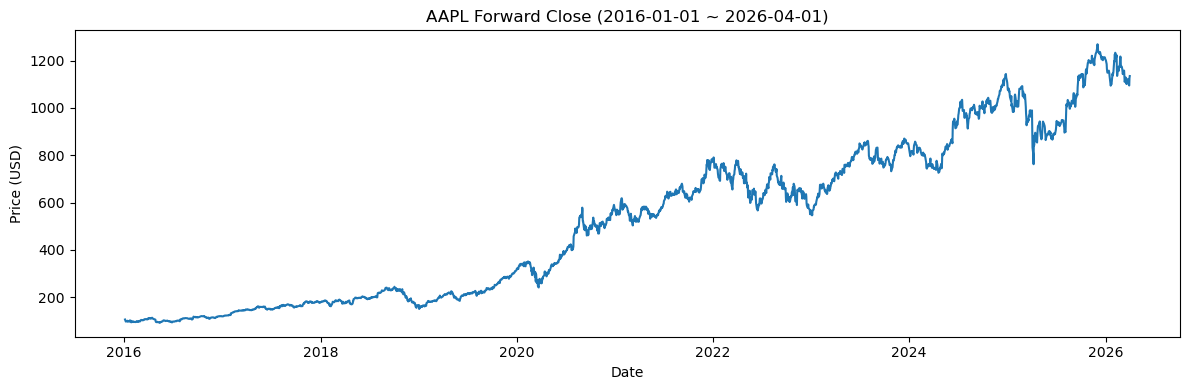

In [21]:
import matplotlib.pyplot as plt

fc = Ctool.calc_forward_close("AAPL", start, end)["AAPL"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fc.index, fc["adjusted_close"])
ax.set_title("AAPL Forward Close (2016-01-01 ~ 2026-04-01)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## Find one way to convert alpha into realized return

In [2]:
date = dt.date(2026, 4, 1)
universe = Ctool.load_universe("SP500", date)['SP500']
value = []
fail = []
df = pd.DataFrame(index=[date], columns=universe)
for ticker in universe:
    try:
        data = Ctool.load_price(ticker, date, date)[ticker]
        value.append((data.high.values[0] - data.low.values[0]) / data.close.values[0])
    except:
        fail.append(ticker)
value = [float((i - np.mean(value)) / np.std(value)) for i in value]
df.loc[date] = value

In [27]:
from scipy.optimize import minimize
rf = 0.03
tickers = df.columns.values.tolist()
returns = Ctool.load_return(tickers, dt.date(2026, 3, 1), date, '1b', group="return")['1b']
alphas = df.values.reshape(-1,)
mean = alphas.mean()
cov = returns.cov()
num_assets = len(alphas)
def objective(weights):
        port_return = np.sum(mean * weights)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
        sharpe = (port_return - rf) / port_vol
        return -sharpe # 我们通过最小化负值来最大化正值
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets]
result = minimize(objective, init_guess, method='SLSQP',
                  bounds=bounds, constraints=constraints)
result.x

array([0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199601,
       0.00199601, 0.00199601, 0.00199601, 0.00199601, 0.00199

In [ ]:
## 用优化的weight计算真实的SR
～～～～～

In [29]:
result

     message: Inequality constraints incompatible
     success: False
      status: 4
         fun: nan
           x: [ 1.996e-03  1.996e-03 ...  1.996e-03  1.996e-03]
         nit: 1
         jac: [       nan        nan ...        nan        nan]
        nfev: 502
        njev: 1
 multipliers: [ 0.000e+00]